# 02. Construção do target de inadimplência em 12 meses

Esse notebook eu vou usar para construir o target da variável resposta principal do projeto.

A regra central desse case é tentar avaliar se o cliente estava inadimplente 12 meses após a concessão do empréstimo. Daí eu vou usar essa variável como target do modelo de credit scoring.

A ideia é separar bem essas três coisas:

1. clientes com janela suficiente para observar 12 meses;
2. clientes sem janela suficiente, que não devem entrar no treino do modelo;
3. clientes sem registro exatamente no mês 12, possivelmente porque a operação já foi quitada antes dessa data.

Além do target principal, também vou criar um target auxiliar de sensibilidade: se o cliente ficou inadimplente em qualquer momento até 12 meses após a concessão.

In [39]:
# Setup básico do notebook.
# Vou manter a mesma estrutura do notebook anterior para facilitar reprodução
# no VSCode, no Jupyter e em uma eventual revisão por outra pessoa.

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.express as px

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    RAW_DIR,
    INTERIM_DIR,
    PROCESSED_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    CONCESSAO_PATH,
    INADIMPLENCIA_PATH,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

registrar_template_credito()

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.4f}".format)

print("Projeto:", PROJECT_ROOT)
print("Interim:", INTERIM_DIR)
print("Processed:", PROCESSED_DIR)

import plotly.io as pio
pio.renderers.default = "notebook_connected+png"

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Interim: C:\GitHub\datascience\projetos\concessao_credito\data\interim
Processed: C:\GitHub\datascience\projetos\concessao_credito\data\processed


## 1. Leitura das bases tratadas

Aqui eu vou usar as bases intermediárias geradas no diagnóstico anterior. Se elas não existirem, o notebook lê os arquivos brutos e aplica as conversões mínimas de data.

Essa alternativa deixa o notebook mais robusto para reprodução.

In [40]:
# Aqui eu tento reaproveitar as bases intermediárias do diagnóstico.
# Se alguém rodar este notebook isoladamente, ele faz a leitura dos CSVs brutos
# e aplica as conversões mínimas necessárias.

concessao_interim_path = INTERIM_DIR / "concessao_diagnostico.parquet"
inadimplencia_interim_path = INTERIM_DIR / "inadimplencia_diagnostico.parquet"

if concessao_interim_path.exists() and inadimplencia_interim_path.exists():
    concessao = pd.read_parquet(concessao_interim_path)
    inadimplencia = pd.read_parquet(inadimplencia_interim_path)
else:
    concessao = pd.read_csv(CONCESSAO_PATH)
    inadimplencia = pd.read_csv(INADIMPLENCIA_PATH)

    for col in ["data_concessao", "data_nascimento", "data_abertura_conta"]:
        concessao[col] = pd.to_datetime(concessao[col], errors="coerce")

    inadimplencia["data_referencia"] = pd.to_datetime(
        inadimplencia["data_referencia"],
        errors="coerce",
    )

print("Shape concessao:", concessao.shape)
print("Shape inadimplencia:", inadimplencia.shape)

display(concessao.head())
display(inadimplencia.head())

Shape concessao: (30000, 17)
Shape inadimplencia: (257960, 3)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda
0,1,2021-12-28,"4,449.8100",621.6600,0.0484,9,"3,574.3200",42.1100,Fundamental Completo,1,78,1968-03-14,2019-09-04,53.7906,2.3162,0.1739,0.0118
1,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013
2,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000
3,4,2022-02-10,"9,704.1400","1,844.5300",0.0389,6,"5,895.2400",59.2600,Não Declarado,0,11,1990-05-15,2020-09-21,31.7426,1.3881,0.3129,0.0101
4,5,2022-04-05,"17,875.2800","3,937.4900",0.0331,5,"6,437.3500",38.0200,Não Declarado,1,69,1968-08-16,2020-10-19,53.6345,1.4593,0.6117,0.0059


,id_cliente,data_referencia,flag_inadimplente
0,1,2022-01-31,0
1,1,2022-02-28,0
2,1,2022-03-31,0
3,1,2022-04-30,0
4,1,2022-05-31,0


## 2. Pequenos ajustes cadastrais antes do target

Antes de construir o target, e vou fazer só alguns ajustes que não alteram a lógica de risco:

- padronizar escolaridade;
- criar um identificador de operação;
- garantir que as datas estejam no formato correto.

Como `id_cliente` está único na base de concessão, ele também representa a operação neste case. Mesmo assim, crio `id_operacao` para deixar a modelagem mais clara.

In [41]:
# Aqui eu padronizo escolaridade porque no diagnóstico apareceu a mesma categoria
# escrita com espaço no final. Isso vai evitar que a modelagem trate categorias iguais
# como se fossem grupos diferentes.

concessao = concessao.copy()
inadimplencia = inadimplencia.copy()

concessao["id_operacao"] = concessao["id_cliente"]

concessao["cat_escolaridade"] = (
    concessao["cat_escolaridade"]
    .astype("string")
    .str.strip()
    .fillna("Não informado")
)

for col in ["data_concessao", "data_nascimento", "data_abertura_conta"]:
    concessao[col] = pd.to_datetime(concessao[col], errors="coerce")

inadimplencia["data_referencia"] = pd.to_datetime(
    inadimplencia["data_referencia"],
    errors="coerce",
)

display(concessao["cat_escolaridade"].value_counts(dropna=False))

cat_escolaridade
Fundamental Incompleto    7768
Não Declarado             4965
Sem Escolaridade          4506
Fundamental Completo      3182
Médio Incompleto          2686
Médio Completo            2308
Superior Incompleto       1871
Superior Completo         1358
Pós-graduação              942
Não informado              414
Name: count, dtype: int64[pyarrow]

## 3. Definição da data de referência de 12 meses

A base de inadimplência é mensal e usa datas de fim de mês. Por isso, para cada concessão, eu vou calcular a referência de 12 meses como o último dia do mês correspondente a 12 meses após a data da concessão.

Exemplo: uma concessão em `2020-10-02` vai ser avaliada em `2021-10-31`.

In [42]:
from pandas.tseries.offsets import MonthEnd

# A referência mensal precisa ficar alinhada com o padrão da base de inadimplência,
# que está registrada no fechamento de cada mês.

concessao["data_ref_12m"] = (
    concessao["data_concessao"] + pd.DateOffset(months=12) + MonthEnd(0)
)

data_max_inadimplencia = inadimplencia["data_referencia"].max()

print("Data máxima disponível na inadimplência:", data_max_inadimplencia)
print("Menor data_ref_12m:", concessao["data_ref_12m"].min())
print("Maior data_ref_12m:", concessao["data_ref_12m"].max())

display(
    concessao[
        ["id_cliente", "data_concessao", "data_ref_12m"]
    ].head()
)

Data máxima disponível na inadimplência: 2022-07-31 00:00:00
Menor data_ref_12m: 2020-08-31 00:00:00
Maior data_ref_12m: 2023-08-31 00:00:00


,id_cliente,data_concessao,data_ref_12m
0,1,2021-12-28,2022-12-31
1,2,2020-10-02,2021-10-31
2,3,2020-10-01,2021-10-31
3,4,2022-02-10,2023-02-28
4,5,2022-04-05,2023-04-30


## 4. Elegibilidade para o target

Nem todo cliente pode ser usado para treinar o modelo de inadimplência em 12 meses.

Se a data de referência de 12 meses for posterior à última data disponível na base de inadimplência, então ainda não houve tempo suficiente para observar o comportamento do cliente. Esses casos eu vou separar eles como `sem_janela_12m`.

Essa decisão vai evitar treinar o modelo com rótulos incompletos.

In [43]:
# Essa regra define quem tem janela suficiente para avaliarmos o mês 12.
# Clientes recentes não vão entrar no treino, mas podem ser pontuados depois,
# quando eu tiver um modelo treinado.

concessao["tem_janela_12m"] = (
    concessao["data_ref_12m"] <= data_max_inadimplencia
)

resumo_janela = (
    concessao
    .groupby("tem_janela_12m", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        data_min_concessao=("data_concessao", "min"),
        data_max_concessao=("data_concessao", "max"),
    )
)

resumo_janela["pct_operacoes"] = (
    resumo_janela["qtd_operacoes"] / len(concessao) * 100
)

display(resumo_janela)

TABLES_DIR.mkdir(parents=True, exist_ok=True)

resumo_janela.to_csv(
    TABLES_DIR / "resumo_janela_target_12m.csv",
    index=False,
    encoding="utf-8-sig",
)

,tem_janela_12m,qtd_operacoes,data_min_concessao,data_max_concessao,pct_operacoes
0,False,10442,2021-08-02,2022-08-18,34.8067
1,True,19558,2019-08-20,2021-07-30,65.1933


## 5. Target principal: inadimplência exatamente no mês 12

Agora eu cruzo a concessão com a base mensal de inadimplência usando:

- `id_cliente`;
- `data_ref_12m` da concessão;
- `data_referencia` da inadimplência.

Quando tiver registro no mês 12, eu uso diretamente a `flag_inadimplente`.

Quando não tiver registro, mas a operação tiver janela suficiente, eu vou assumir que o cliente não estava inadimplente no mês 12. Essa premissa é coerente com o enunciado, porque a base mensal acompanha o cliente até a quitação; se não tem registro no mês 12 e já tinha janela para observar ele, a operação provavelmente foi encerrada antes desse ponto.

Mesmo assim, eu vou marcar a origem do target para deixar essa premissa auditável posteriormente.

In [44]:
# Eu preparo uma versão enxuta da base mensal para fazer o cruzamento do mês 12.
# Se por algum motivo tiver mais de um registro no mesmo cliente/mês,
# fico com o maior valor da flag, que é a leitura mais conservadora.

inad_12m_base = (
    inadimplencia
    .groupby(["id_cliente", "data_referencia"], as_index=False)
    .agg(flag_inadimplente_12m_observado=("flag_inadimplente", "max"))
)

base_target = concessao.merge(
    inad_12m_base,
    left_on=["id_cliente", "data_ref_12m"],
    right_on=["id_cliente", "data_referencia"],
    how="left",
)

base_target = base_target.drop(columns=["data_referencia"])

display(base_target.head())

,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta,idade_concessao,tempo_conta_anos,comprometimento_renda,restritivos_sobre_renda,id_operacao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado
0,1,2021-12-28,"4,449.8100",621.6600,0.0484,9,"3,574.3200",42.1100,Fundamental Completo,1,78,1968-03-14,2019-09-04,53.7906,2.3162,0.1739,0.0118,1,2022-12-31,False,NaN
1,2,2020-10-02,"12,822.7800","1,119.3900",0.0358,15,"4,140.8700",5.2100,Médio Incompleto,1,89,1975-08-01,2019-12-06,45.1718,0.8241,0.2703,0.0013,2,2021-10-31,True,0.0000
2,3,2020-10-01,"11,683.1500","1,540.4700",0.0357,9,"2,505.7400",0.0000,Médio Incompleto,1,61,1988-05-03,2019-10-22,32.4134,0.9446,0.6148,0.0000,3,2021-10-31,True,NaN
3,4,2022-02-10,"9,704.1400","1,844.5300",0.0389,6,"5,895.2400",59.2600,Não Declarado,0,11,1990-05-15,2020-09-21,31.7426,1.3881,0.3129,0.0101,4,2023-02-28,False,NaN
4,5,2022-04-05,"17,875.2800","3,937.4900",0.0331,5,"6,437.3500",38.0200,Não Declarado,1,69,1968-08-16,2020-10-19,53.6345,1.4593,0.6117,0.0059,5,2023-04-30,False,NaN


In [45]:
# O target principal só é válido para clientes com janela completa.
# Para clientes sem janela, eu vou manter o target como nulo para não contaminar
# o treino do modelo.

base_target["target_inadimplente_12m"] = np.where(
    base_target["tem_janela_12m"],
    base_target["flag_inadimplente_12m_observado"].fillna(0),
    np.nan,
)

base_target["origem_target_12m"] = np.select(
    [
        ~base_target["tem_janela_12m"],
        base_target["flag_inadimplente_12m_observado"].notna(),
        base_target["tem_janela_12m"] & base_target["flag_inadimplente_12m_observado"].isna(),
    ],
    [
        "sem_janela_12m",
        "observado_no_mes_12",
        "sem_registro_no_mes_12_assumido_quitado",
    ],
    default="verificar",
)

base_target["target_inadimplente_12m"] = (
    base_target["target_inadimplente_12m"]
    .astype("float")
)

display(
    base_target[
        [
            "id_cliente",
            "data_concessao",
            "data_ref_12m",
            "tem_janela_12m",
            "flag_inadimplente_12m_observado",
            "target_inadimplente_12m",
            "origem_target_12m",
        ]
    ].head(10)
)

,id_cliente,data_concessao,data_ref_12m,tem_janela_12m,flag_inadimplente_12m_observado,target_inadimplente_12m,origem_target_12m
0,1,2021-12-28,2022-12-31,False,NaN,NaN,sem_janela_12m
1,2,2020-10-02,2021-10-31,True,0.0000,0.0000,observado_no_mes_12
2,3,2020-10-01,2021-10-31,True,NaN,0.0000,sem_registro_no_mes_12_assumido_quitado
3,4,2022-02-10,2023-02-28,False,NaN,NaN,sem_janela_12m
4,5,2022-04-05,2023-04-30,False,NaN,NaN,sem_janela_12m
5,6,2022-03-03,2023-03-31,False,NaN,NaN,sem_janela_12m
6,7,2021-12-27,2022-12-31,False,NaN,NaN,sem_janela_12m
7,8,2021-12-14,2022-12-31,False,NaN,NaN,sem_janela_12m
8,9,2020-06-05,2021-06-30,True,0.0000,0.0000,observado_no_mes_12
9,10,2021-10-25,2022-10-31,False,NaN,NaN,sem_janela_12m


## 6. Target auxiliar: inadimplência em qualquer momento até 12 meses

Além do target principal, eu vou criar uma variável auxiliar indicando se o cliente ficou inadimplente em qualquer mês entre a concessão e a referência de 12 meses.

Essa variável não vai substituir o target principal, porque o enunciado/problema/dor fala especificamente do mês 12. Mas ela ajuda na análise de sensibilidade: um cliente pode estar regular no mês 12, mas ter atrasado em meses anteriores.

In [46]:
# Para o target auxiliar, eu considero qualquer registro de inadimplência entre
# o mês seguinte à concessão e o mês de referência de 12 meses.

janela_auxiliar = (
    base_target[["id_cliente", "id_operacao", "data_concessao", "data_ref_12m", "tem_janela_12m"]]
    .merge(inadimplencia, on="id_cliente", how="left")
)

janela_auxiliar = janela_auxiliar[
    (janela_auxiliar["data_referencia"] > janela_auxiliar["data_concessao"])
    & (janela_auxiliar["data_referencia"] <= janela_auxiliar["data_ref_12m"])
]

target_ever_12m = (
    janela_auxiliar
    .groupby("id_operacao", as_index=False)
    .agg(target_inadimplente_ate_12m=("flag_inadimplente", "max"))
)

base_target = base_target.merge(
    target_ever_12m,
    on="id_operacao",
    how="left",
)

base_target["target_inadimplente_ate_12m"] = np.where(
    base_target["tem_janela_12m"],
    base_target["target_inadimplente_ate_12m"].fillna(0),
    np.nan,
)

display(
    base_target[
        [
            "id_cliente",
            "target_inadimplente_12m",
            "target_inadimplente_ate_12m",
            "origem_target_12m",
        ]
    ].head()
)

,id_cliente,target_inadimplente_12m,target_inadimplente_ate_12m,origem_target_12m
0,1,NaN,NaN,sem_janela_12m
1,2,0.0000,0.0000,observado_no_mes_12
2,3,0.0000,0.0000,sem_registro_no_mes_12_assumido_quitado
3,4,NaN,NaN,sem_janela_12m
4,5,NaN,NaN,sem_janela_12m


## 7. Resumo do target criado

Aqui eu verifico a distribuição do target principal e do target auxiliar.

Essa etapa é super importante antes da modelagem porque problemas de crédito costumam ter desbalanceamento entre bons e maus pagadores. Se a inadimplência for muito baixa, métricas como acurácia podem ser enganosas; por isso, mais à frente eu vou avaliar AUC, KS, recall, precisão e métricas por faixa de score.

In [47]:
base_modelagem = base_target[base_target["tem_janela_12m"]].copy()
base_sem_janela = base_target[~base_target["tem_janela_12m"]].copy()

resumo_target = pd.DataFrame({
    "indicador": [
        "operacoes_total",
        "operacoes_com_janela_12m",
        "operacoes_sem_janela_12m",
        "taxa_target_12m",
        "taxa_target_ate_12m",
    ],
    "valor": [
        len(base_target),
        len(base_modelagem),
        len(base_sem_janela),
        base_modelagem["target_inadimplente_12m"].mean(),
        base_modelagem["target_inadimplente_ate_12m"].mean(),
    ],
})

display(resumo_target)

resumo_origem_target = (
    base_target
    .groupby("origem_target_12m", as_index=False)
    .agg(qtd_operacoes=("id_operacao", "count"))
)

resumo_origem_target["pct_operacoes"] = (
    resumo_origem_target["qtd_operacoes"] / len(base_target) * 100
)

display(resumo_origem_target)

resumo_target.to_csv(
    TABLES_DIR / "resumo_target_12m.csv",
    index=False,
    encoding="utf-8-sig",
)

resumo_origem_target.to_csv(
    TABLES_DIR / "resumo_origem_target_12m.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,valor
0,operacoes_total,"30,000.0000"
1,operacoes_com_janela_12m,"19,558.0000"
2,operacoes_sem_janela_12m,"10,442.0000"
3,taxa_target_12m,0.1231
4,taxa_target_ate_12m,0.1231


,origem_target_12m,qtd_operacoes,pct_operacoes
0,observado_no_mes_12,7671,25.5700
1,sem_janela_12m,10442,34.8067
2,sem_registro_no_mes_12_assumido_quitado,11887,39.6233


,target_label,qtd_operacoes,pct_operacoes
0,Adimplente no mês 12,17151,87.6930
1,Inadimplente no mês 12,2407,12.3070


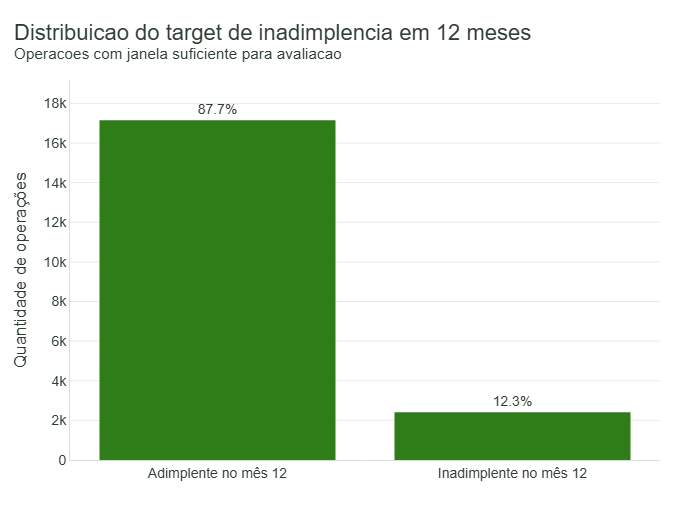

In [48]:
dist_target = (
    base_modelagem
    .assign(
        target_label=np.where(
            base_modelagem["target_inadimplente_12m"] == 1,
            "Inadimplente no mês 12",
            "Adimplente no mês 12",
        )
    )
    .groupby("target_label", as_index=False)
    .agg(qtd_operacoes=("id_operacao", "count"))
)

dist_target["pct_operacoes"] = (
    dist_target["qtd_operacoes"] / dist_target["qtd_operacoes"].sum() * 100
)

display(dist_target)

fig = px.bar(
    dist_target,
    x="target_label",
    y="qtd_operacoes",
    text="pct_operacoes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do target de inadimplencia em 12 meses",
    subtitulo="Operacoes com janela suficiente para avaliacao",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "distribuicao_target_12m.html",
)

## 8. Taxa de inadimplência por safra de concessão

Agora eu vou olhar a taxa de inadimplência em 12 meses por mês de concessão.

Essa análise aqui vai me ajudar a entender se o risco é estável ao longo do tempo. Se tiver muita oscilação entre safras, a validação temporal do modelo vai ser ainda mais importante.

In [49]:
target_por_safra = (
    base_modelagem
    .assign(
        mes_concessao=base_modelagem["data_concessao"].dt.to_period("M").astype(str)
    )
    .groupby("mes_concessao", as_index=False)
    .agg(
        qtd_operacoes=("id_operacao", "count"),
        taxa_inadimplencia_12m=("target_inadimplente_12m", "mean"),
        taxa_inadimplencia_ate_12m=("target_inadimplente_ate_12m", "mean"),
        valor_medio=("valor_emprestado", "mean"),
        comprometimento_medio=("comprometimento_renda", "mean"),
    )
)

target_por_safra["taxa_inadimplencia_12m_pct"] = (
    target_por_safra["taxa_inadimplencia_12m"] * 100
)

target_por_safra["taxa_inadimplencia_ate_12m_pct"] = (
    target_por_safra["taxa_inadimplencia_ate_12m"] * 100
)

display(target_por_safra.head())

target_por_safra.to_csv(
    TABLES_DIR / "target_por_safra_concessao.csv",
    index=False,
    encoding="utf-8-sig",
)

,mes_concessao,qtd_operacoes,taxa_inadimplencia_12m,taxa_inadimplencia_ate_12m,valor_medio,comprometimento_medio,taxa_inadimplencia_12m_pct,taxa_inadimplencia_ate_12m_pct
0,2019-08,364,0.1401,0.1401,"13,581.7971",0.5069,14.0110,14.0110
1,2019-09,821,0.1181,0.1181,"13,323.3995",0.5060,11.8149,11.8149
2,2019-10,863,0.1321,0.1321,"13,815.8615",0.5063,13.2097,13.2097
3,2019-11,816,0.1201,0.1201,"12,106.7246",0.4968,12.0098,12.0098
4,2019-12,829,0.1279,0.1279,"12,596.0910",0.4883,12.7865,12.7865


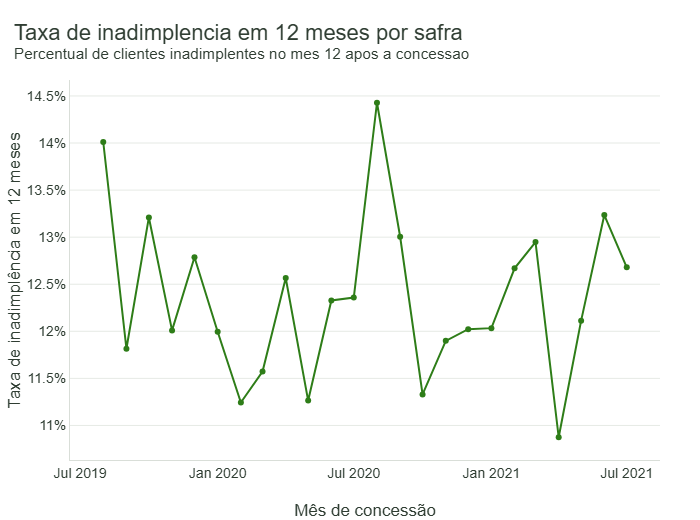

In [50]:
fig = px.line(
    target_por_safra,
    x="mes_concessao",
    y="taxa_inadimplencia_12m_pct",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Taxa de inadimplencia em 12 meses por safra",
    subtitulo="Percentual de clientes inadimplentes no mes 12 apos a concessao",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de concessão")
fig.update_yaxes(title="Taxa de inadimplência em 12 meses", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "taxa_inadimplencia_12m_por_safra.html",
)

## 9. Primeiras leituras de risco por variável

Antes da EDA completa, eu vou fazer uma leitura rápida da taxa de inadimplência por algumas variáveis importantes.

A minha ideia aqui não é concluir a política ainda, mas identificar se o target que eu criei tá fazendo sentido frente a variáveis de crédito, como renda, comprometimento, restritivos e prazo.

In [51]:
def criar_faixas_quantis(df, coluna, qtd_faixas=5):
    """
    aqui eu crio faixas por quantis para leitura exploratória.

    eu uso quantis porque eles tendem a distribuir melhor o volume entre grupos,
    facilita bastante para comparar a taxa de inadimplência sem deixar faixas muito vazias.
    """
    return pd.qcut(
        df[coluna],
        q=qtd_faixas,
        duplicates="drop",
    )


variaveis_para_faixas = [
    "valor_renda",
    "valor_emprestado",
    "valor_parcela",
    "comprometimento_renda",
    "valor_restritivos",
    "restritivos_sobre_renda",
]

for col in variaveis_para_faixas:
    nome_faixa = f"fx_{col}"
    base_modelagem[nome_faixa] = criar_faixas_quantis(base_modelagem, col)

In [52]:
def resumo_risco_por_faixa(df, coluna_faixa):
    """
    essa função é ara consolidar o volume e taxa de inadimplência por faixa.

    ela vai ser reaproveitada na EDA para entender quais variáveis
    parecem separar melhor bons e maus pagadores.
    """
    resumo = (
        df
        .groupby(coluna_faixa, observed=True, as_index=False)
        .agg(
            qtd_operacoes=("id_operacao", "count"),
            taxa_inadimplencia_12m=("target_inadimplente_12m", "mean"),
            valor_medio=("valor_emprestado", "mean"),
            renda_media=("valor_renda", "mean"),
            comprometimento_medio=("comprometimento_renda", "mean"),
        )
    )

    resumo["taxa_inadimplencia_12m_pct"] = (
        resumo["taxa_inadimplencia_12m"] * 100
    )

    resumo[coluna_faixa] = resumo[coluna_faixa].astype(str)

    return resumo


resumos_faixas = {}

for col in variaveis_para_faixas:
    coluna_faixa = f"fx_{col}"
    resumos_faixas[col] = resumo_risco_por_faixa(base_modelagem, coluna_faixa)

    print(f"\nResumo por faixa de {col}")
    display(resumos_faixas[col])


Resumo por faixa de valor_renda


,fx_valor_renda,qtd_operacoes,taxa_inadimplencia_12m,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_12m_pct
0,"(1199.999, 1804.064]",3912,0.1299,"5,102.3644","1,420.6610",0.4952,12.9857
1,"(1804.064, 2575.78]",3911,0.1319,"7,955.8264","2,185.0078",0.5005,13.1936
2,"(2575.78, 3478.248]",3912,0.1191,"10,869.2819","2,999.7959",0.4974,11.9121
3,"(3478.248, 5003.316]",3911,0.1243,"15,052.7638","4,158.4164",0.4999,12.4265
4,"(5003.316, 30758.56]",3912,0.1102,"26,644.2779","7,318.7621",0.5005,11.0174



Resumo por faixa de valor_emprestado


,fx_valor_emprestado,qtd_operacoes,taxa_inadimplencia_12m,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_12m_pct
0,"(344.97900000000004, 4085.724]",3912,0.0723,"2,612.5112","2,159.1396",0.2830,7.2342
1,"(4085.724, 7249.594]",3911,0.1102,"5,611.8335","2,779.4309",0.4187,11.0202
2,"(7249.594, 11630.72]",3912,0.1408,"9,254.1970","3,179.3691",0.5202,14.0849
3,"(11630.72, 19467.92]",3911,0.1442,"15,064.8149","3,916.6027",0.5941,14.4209
4,"(19467.92, 162511.33]",3912,0.1478,"33,080.5616","6,048.1911",0.6774,14.7751



Resumo por faixa de valor_parcela


...

,fx_comprometimento_renda,qtd_operacoes,taxa_inadimplencia_12m,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_12m_pct
0,"(0.099, 0.258]",3912,0.0171,"4,659.2140","3,601.5892",0.1795,1.7127
1,"(0.258, 0.416]",3911,0.1304,"8,772.7817","3,615.5706",0.3359,13.0401
2,"(0.416, 0.58]",3912,0.1501,"12,778.0220","3,550.7912",0.4992,15.0051
3,"(0.58, 0.74]",3911,0.1631,"17,435.9392","3,629.4777",0.6591,16.3130
4,"(0.74, 0.9]",3912,0.1547,"21,979.3755","3,685.4449",0.8197,15.4652



Resumo por faixa de valor_restritivos


,fx_valor_restritivos,qtd_operacoes,taxa_inadimplencia_12m,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_12m_pct
0,"(-0.001, 4.438]",7823,0.0699,"13,072.5857","3,592.3656",0.5017,6.9922
1,"(4.438, 42.52]",3913,0.0756,"13,105.5701","3,625.4345",0.4973,7.5645
2,"(42.52, 103.558]",3910,0.1818,"13,204.8858","3,588.9948",0.4946,18.1841
3,"(103.558, 1231.35]",3912,0.2180,"13,169.7480","3,683.6875",0.4980,21.8047



Resumo por faixa de restritivos_sobre_renda


,fx_restritivos_sobre_renda,qtd_operacoes,taxa_inadimplencia_12m,valor_medio,renda_media,comprometimento_medio,taxa_inadimplencia_12m_pct
0,"(-0.001, 0.00125]",7823,0.0695,"13,494.3306","3,696.1592",0.5017,6.9539
1,"(0.00125, 0.013]",3912,0.0913,"16,588.8146","4,583.5435",0.4977,9.1258
2,"(0.013, 0.0353]",3911,0.1680,"13,106.3416","3,620.0990",0.4976,16.7988
3,"(0.0353, 0.522]",3912,0.2170,"8,941.6151","2,486.9310",0.4946,21.7025


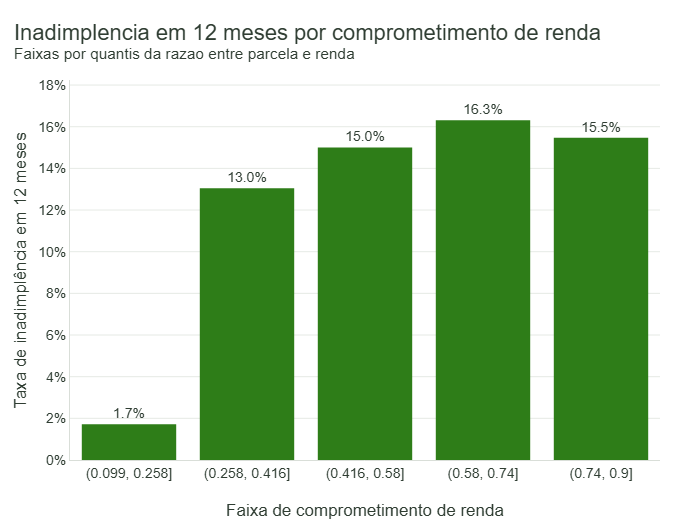

In [53]:
resumo_comprometimento = resumos_faixas["comprometimento_renda"]

fig = px.bar(
    resumo_comprometimento,
    x="fx_comprometimento_renda",
    y="taxa_inadimplencia_12m_pct",
    text="taxa_inadimplencia_12m_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por comprometimento de renda",
    subtitulo="Faixas por quantis da razao entre parcela e renda",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Faixa de comprometimento de renda")
fig.update_yaxes(title="Taxa de inadimplência em 12 meses", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "inadimplencia_12m_por_comprometimento.html",
)

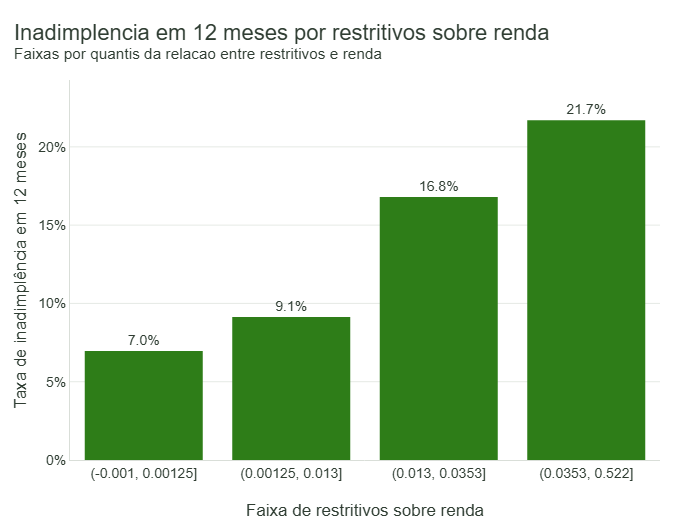

In [54]:
resumo_restritivos = resumos_faixas["restritivos_sobre_renda"]

fig = px.bar(
    resumo_restritivos,
    x="fx_restritivos_sobre_renda",
    y="taxa_inadimplencia_12m_pct",
    text="taxa_inadimplencia_12m_pct",
)

fig = aplicar_layout(
    fig,
    titulo="Inadimplencia em 12 meses por restritivos sobre renda",
    subtitulo="Faixas por quantis da relacao entre restritivos e renda",
    mostrar_legenda=False,
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
)

fig.update_xaxes(title="Faixa de restritivos sobre renda")
fig.update_yaxes(title="Taxa de inadimplência em 12 meses", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "inadimplencia_12m_por_restritivos_sobre_renda.html",
)

## 10. Salvamento da base de modelagem

salvo duas bases:

1. `base_modelagem_12m.parquet`: somente operações com target observável;
2. `base_scoring_sem_janela_12m.parquet`: operações recentes, sem janela suficiente, que não entram no treino.

Essa separação é importante porque a política final pode ser aplicada a novos clientes, mas o treino do modelo tem que usar só casos com target confiável.

In [55]:
# Antes de salvar em parquet, eu vou fazer uma cópia das bases.
# Algumas colunas criadas com pd.qcut ficam como intervalos do pandas,
# e o pyarrow pode não conseguir gravar esse tipo diretamente (no caso deu erro na primeira tentativa).
# Converter essas faixas para texto preserva a informação e evita erro
# na reprodução do projeto.

def preparar_para_parquet(df):
    df_saida = df.copy()

    for col in df_saida.columns:
        if pd.api.types.is_interval_dtype(df_saida[col]):
            df_saida[col] = df_saida[col].astype(str)

        elif pd.api.types.is_categorical_dtype(df_saida[col]):
            df_saida[col] = df_saida[col].astype(str)

    return df_saida


PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

base_modelagem_parquet = preparar_para_parquet(base_modelagem)
base_sem_janela_parquet = preparar_para_parquet(base_sem_janela)
base_target_parquet = preparar_para_parquet(base_target)

base_modelagem_parquet.to_parquet(
    PROCESSED_DIR / "base_modelagem_12m.parquet",
    index=False,
)

base_sem_janela_parquet.to_parquet(
    PROCESSED_DIR / "base_scoring_sem_janela_12m.parquet",
    index=False,
)

base_target_parquet.to_parquet(
    PROCESSED_DIR / "base_concessao_com_target_12m.parquet",
    index=False,
)

print("Base de modelagem salva em:", PROCESSED_DIR / "base_modelagem_12m.parquet")
print("Base sem janela salva em:", PROCESSED_DIR / "base_scoring_sem_janela_12m.parquet")
print("Base completa com target salva em:", PROCESSED_DIR / "base_concessao_com_target_12m.parquet")

C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:11: Pandas4Warning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:11: Pandas4Warning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif 

Base de modelagem salva em: C:\GitHub\datascience\projetos\concessao_credito\data\processed\base_modelagem_12m.parquet
Base sem janela salva em: C:\GitHub\datascience\projetos\concessao_credito\data\processed\base_scoring_sem_janela_12m.parquet
Base completa com target salva em: C:\GitHub\datascience\projetos\concessao_credito\data\processed\base_concessao_com_target_12m.parquet


C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:11: Pandas4Warning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:11: Pandas4Warning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(df_saida[col]):
C:\Users\ariel\AppData\Local\Temp\ipykernel_9268\4020633830.py:14: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif 

## 12. Conclusões da construção do target

A construção do target de inadimplência em 12 meses foi concluída aqui.

A base original de concessão possui 30.000 operações. Dessas, 19.558 possuem janela suficiente para observar o comportamento do cliente 12 meses após a contratação do empréstimo. As outras 10.442 operações foram separadas da base de treino porque a data de referência de 12 meses é posterior à última data disponível na base de inadimplência.

Essa separação é importante pra evitar rótulos incompletos. Em crédito, treinar um modelo com operações que ainda não tiveram tempo suficiente para maturar pode distorcer a taxa de inadimplência e fazer o modelo aprender um risco artificialmente baixo.

### Bases geradas para as próximas etapas

Aqui eu gerei três bases processadas:

- `base_modelagem_12m.parquet`: operações com target observável, que eu vou usar na EDA e na modelagem;
- `base_scoring_sem_janela_12m.parquet`: operações recentes, sem janela suficiente para treino, mas elas são úteis como exemplo de aplicação futura da política;
- `base_concessao_com_target_12m.parquet`: base completa com a marcação de target, janela e origem da classificação.

Na próxima etapa, eu vou aprofundar a análise exploratória de crédito usando apenas a base com janela válida. O foco vai ser entender quais variáveis mais explicam a inadimplência e quais cortes podem ser transformados em regras de política.